#### Importing Required Libraries


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from collections import Counter
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings('ignore')

# Setting style for plots
plt.style.use('ggplot')
sns.set_palette('viridis')

#### Loading the Data

In [2]:
# Loading my dataset
df = pd.read_csv('dataset/data.csv', sep=';')

# Showing the first 5 rows
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


#### Exploring Data Basics

In [3]:
# Checking the dimensions of the dataset and null values
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (4424, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualif

In [4]:
print("Columns in dataset:")
print(df.columns)


Columns in dataset:
Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       '

In [5]:
print("Duplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [6]:
# Looking at summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance\t,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [7]:
# Checking for any null values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values[missing_values > 0])

Missing Values:
 Series([], dtype: int64)


#### Doing Exploratory Data Analysis (EDA)

#### Target Variable Distribution

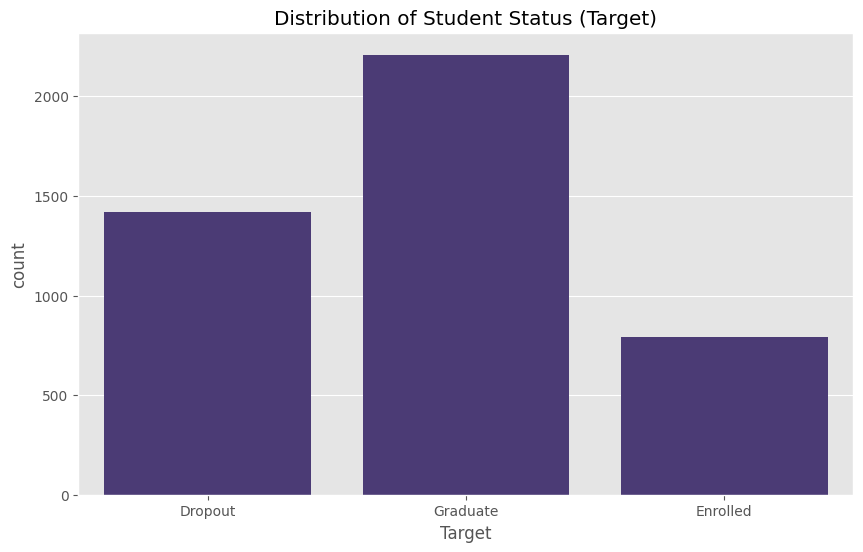

In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Target')
plt.title('Distribution of Student Status (Target)')
plt.show()

In [9]:
print(df['Target'].value_counts())
print(df['Target'].value_counts(normalize=True)*100)


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


#### Age at Enrollment vs Target

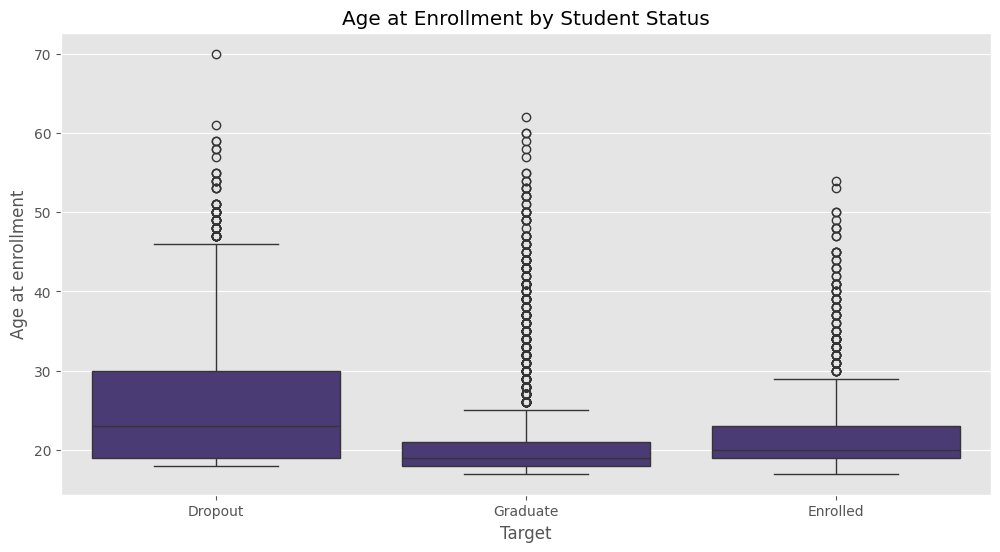

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Target', y='Age at enrollment')
plt.title('Age at Enrollment by Student Status')
plt.show()

#### Academic Performance (1st Sem vs 2nd Sem Grade)

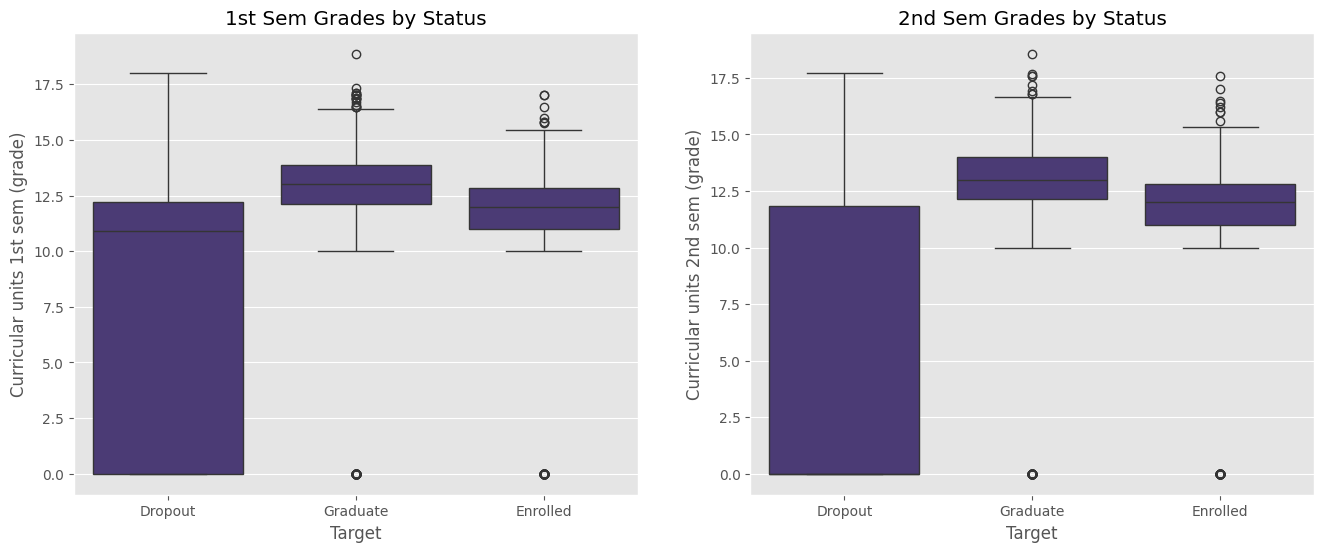

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='Target', y='Curricular units 1st sem (grade)', ax=ax[0])
ax[0].set_title('1st Sem Grades by Status')

sns.boxplot(data=df, x='Target', y='Curricular units 2nd sem (grade)', ax=ax[1])
ax[1].set_title('2nd Sem Grades by Status')

plt.show()

#### Gender and Scholarship Status

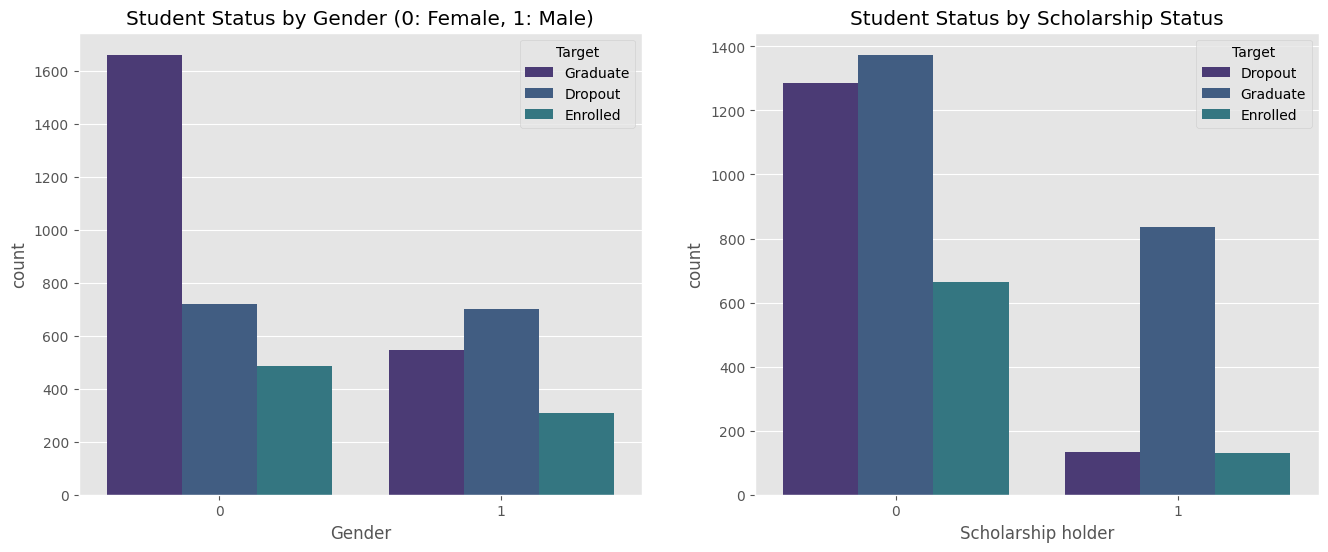

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x='Gender', hue='Target', ax=ax[0])
ax[0].set_title('Student Status by Gender (0: Female, 1: Male)')

sns.countplot(data=df, x='Scholarship holder', hue='Target', ax=ax[1])
ax[1].set_title('Student Status by Scholarship Status')

plt.show()

#### Correlation Heatmap

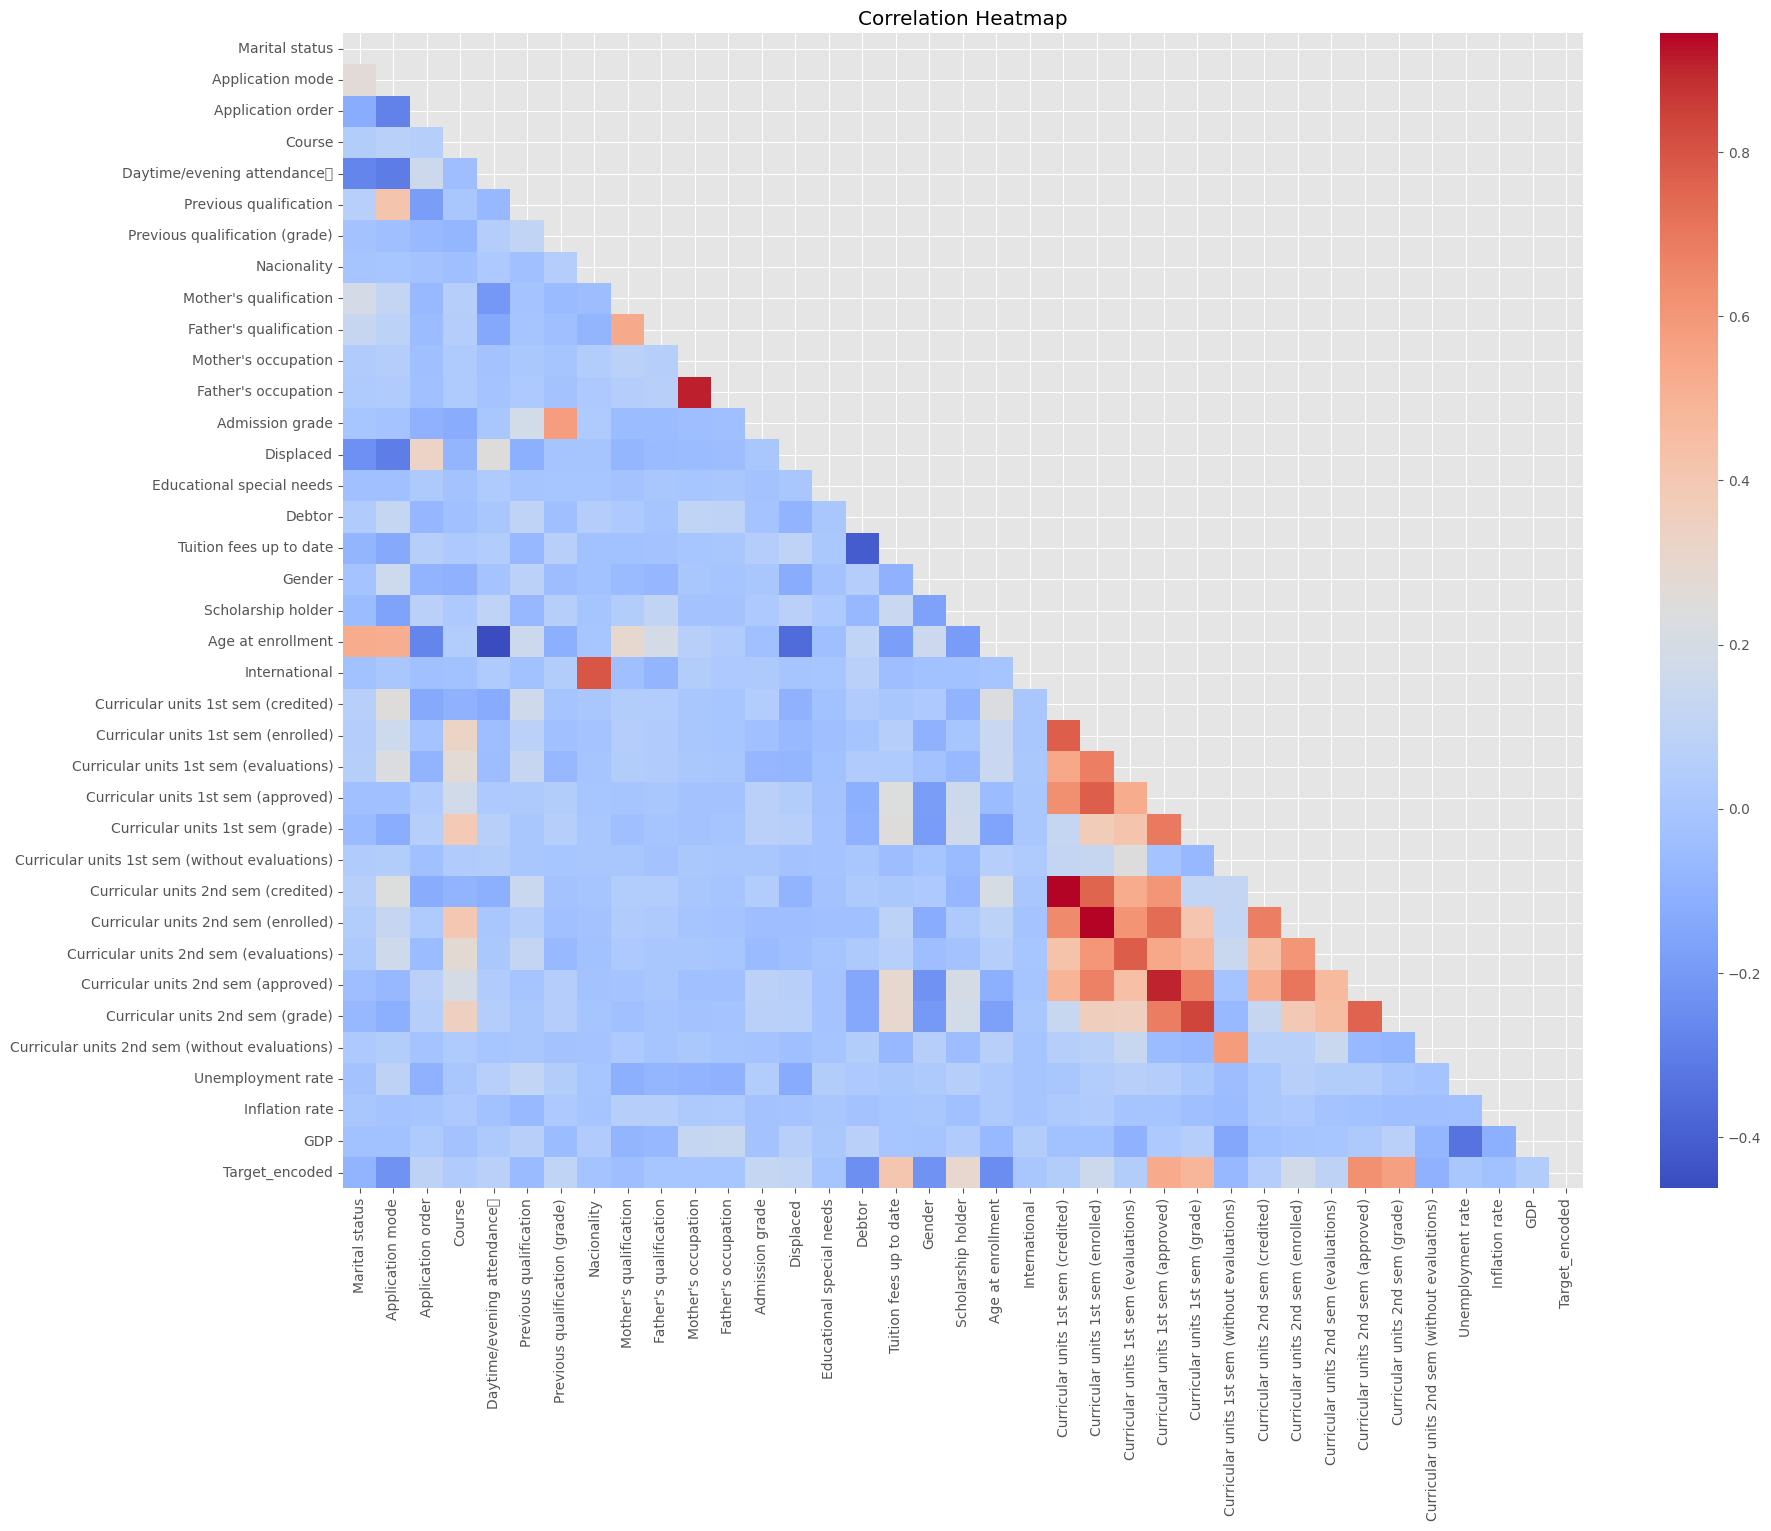

In [13]:
# Encoding target variable for correlation calculation
df_corr = df.copy()
df_corr['Target_encoded'] = df_corr['Target'].map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})

plt.figure(figsize=(20, 15))
mask = np.triu(np.ones_like(df_corr.select_dtypes(include=[np.number]).corr(), dtype=bool))
sns.heatmap(df_corr.select_dtypes(include=[np.number]).corr(), mask=mask, annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

#### Preprocessing the Data

In [14]:

# Preparing features (X) and target (y)
X = df.drop('Target', axis=1)
y = df['Target']

# Encoding the categorical target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Detected Classes:", le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Detected Classes: ['Dropout' 'Enrolled' 'Graduate']


BSMOTE to handle Class Imbalance 

Original training set distribution:
Counter({2: 1767, 0: 1137, 1: 635})

After applying BorderlineSMOTE:
Counter({2: 1767, 0: 1767, 1: 1767})


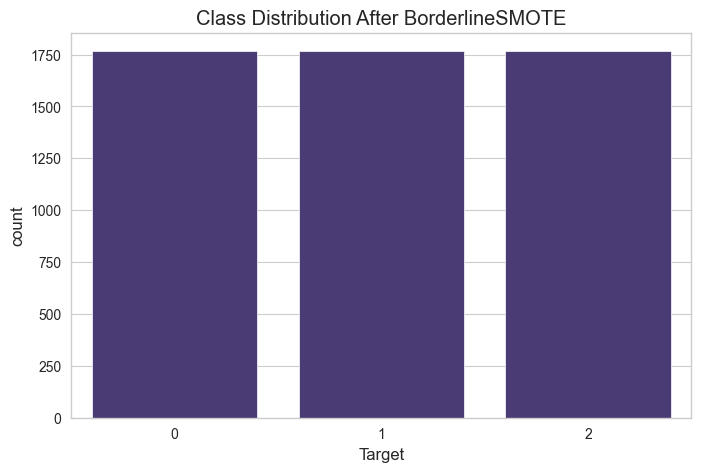

In [15]:

# Apply BSMOTE only on training data
bsmote = BorderlineSMOTE(random_state=42)
X_train_res, y_train_res = bsmote.fit_resample(X_train, y_train)
print("Original training set distribution:")
print(Counter(y_train))
print("\nAfter applying BorderlineSMOTE:")
print(Counter(y_train_res))
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))
df_resampled = pd.DataFrame(X_train_res, columns=X.columns)
df_resampled['Target'] = y_train_res
sns.countplot(data=df_resampled, x='Target')
plt.title("Class Distribution After BorderlineSMOTE")
plt.show()


Calculating Feature Importnce

Accuracy: 0.7717514124293785

Classification Report:
               precision    recall  f1-score   support

     Dropout       0.82      0.75      0.79       284
    Enrolled       0.52      0.53      0.52       159
    Graduate       0.83      0.87      0.85       442

    accuracy                           0.77       885
   macro avg       0.72      0.72      0.72       885
weighted avg       0.77      0.77      0.77       885



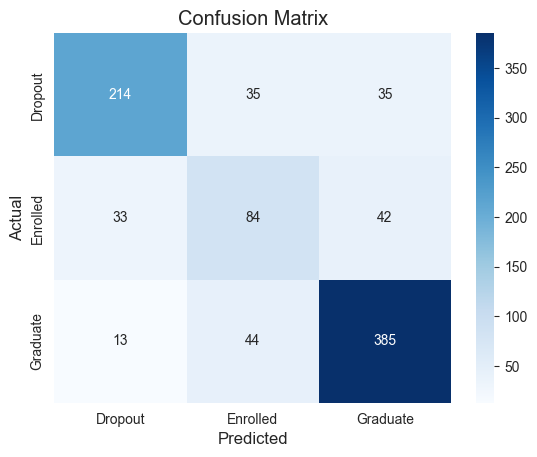

Top 20 Important Features:
 Curricular units 2nd sem (approved)       0.134130
Curricular units 1st sem (approved)       0.084330
Curricular units 2nd sem (grade)          0.069446
Curricular units 1st sem (grade)          0.056262
Curricular units 2nd sem (evaluations)    0.046398
Curricular units 1st sem (evaluations)    0.044949
Age at enrollment                         0.042473
Admission grade                           0.038045
Previous qualification (grade)            0.036388
Tuition fees up to date                   0.035364
Course                                    0.032223
Father's occupation                       0.029921
Curricular units 2nd sem (enrolled)       0.028864
Mother's occupation                       0.028652
Curricular units 1st sem (enrolled)       0.027135
GDP                                       0.026258
Unemployment rate                         0.025234
Mother's qualification                    0.025158
Application mode                          0.025137
Fat

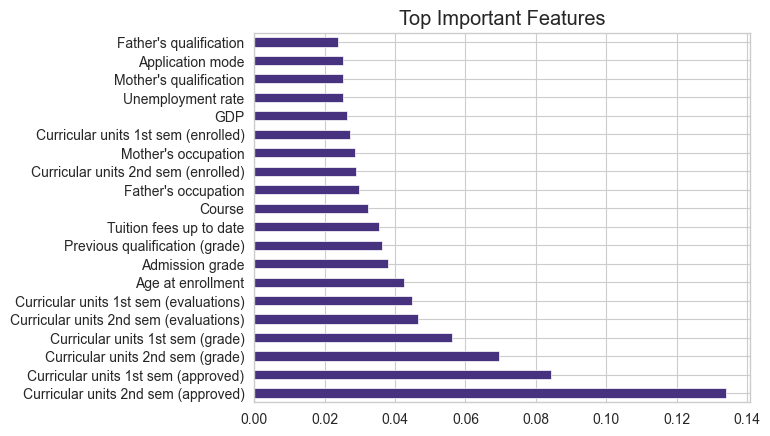

In [16]:
rf_model = RandomForestClassifier(n_estimators=300)
rf_model.fit(X_train_res, y_train_res)
y_pred = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 20 Important Features:\n", feature_importance.head(20))
feature_importance.head(20).plot(kind='barh')
plt.title("Top Important Features")
plt.show()


In [17]:
# Selecting the top 20 features for modeling
top_features = feature_importance.head(20).index

# Getting their indices from the original dataframe's columns
top_feature_indices = [list(X.columns).index(f) for f in top_features]

# Slicing our training and test arrays to include only the best features
X_train_best = X_train_res[:, top_feature_indices]
X_test_best = X_test[:, top_feature_indices]

print(f"Shape of X_train_best: {X_train_best.shape}")
print(f"Shape of X_test_best: {X_test_best.shape}")


Shape of X_train_best: (5301, 20)
Shape of X_test_best: (885, 20)


# Logistic Regression

Best Parameters (Logistic Regression): {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}

Accuracy Score: 0.7401129943502824

Classification Report:
               precision    recall  f1-score   support

     Dropout       0.81      0.72      0.76       284
    Enrolled       0.45      0.63      0.53       159
    Graduate       0.85      0.79      0.82       442

    accuracy                           0.74       885
   macro avg       0.70      0.71      0.70       885
weighted avg       0.77      0.74      0.75       885



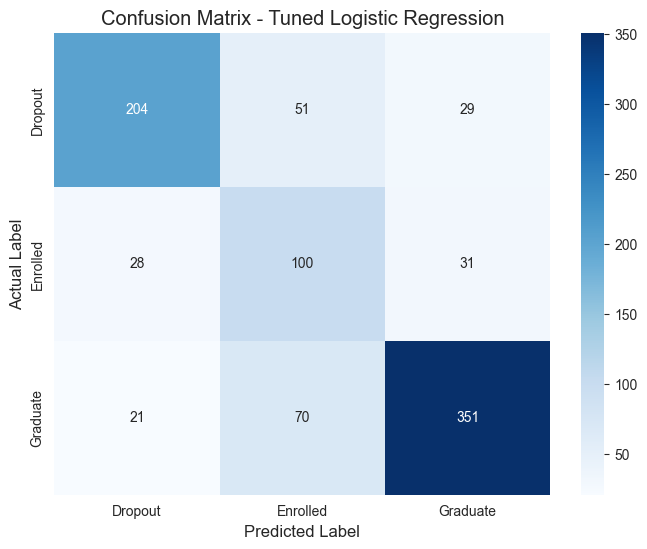

In [18]:
param_grid_lr = {
    'C': [0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}

grid_lr = GridSearchCV(LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42), 
                       param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train_best, y_train_res)

best_lr = grid_lr.best_estimator_
print("Best Parameters (Logistic Regression):", grid_lr.best_params_)

y_pred_lr = best_lr.predict(X_test_best)
print("\nAccuracy Score:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr, target_names=le.classes_))
plt.figure(figsize=(8, 6))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Tuned Logistic Regression')
plt.show()


# Decision Tree 

Best Parameters (Decision Tree): {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}

Accuracy: 0.6892655367231638
              precision    recall  f1-score   support

     Dropout       0.73      0.68      0.70       284
    Enrolled       0.36      0.44      0.40       159
    Graduate       0.81      0.79      0.80       442

    accuracy                           0.69       885
   macro avg       0.63      0.63      0.63       885
weighted avg       0.70      0.69      0.70       885



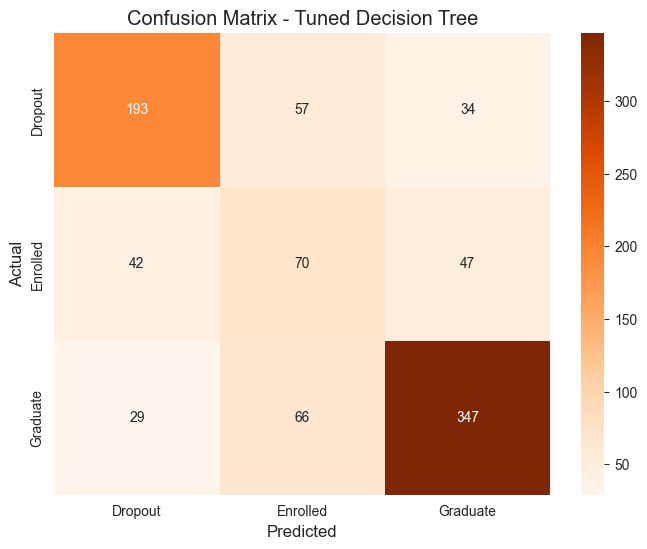

In [19]:
param_grid_dt = {
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
grid_dt = GridSearchCV(DecisionTreeClassifier(class_weight='balanced', random_state=42), 
                       param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1)
grid_dt.fit(X_train_best, y_train_res)
best_dt = grid_dt.best_estimator_
print("Best Parameters (Decision Tree):", grid_dt.best_params_)
y_pred_dt = best_dt.predict(X_test_best)
print("\nAccuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

plt.figure(figsize=(8, 6))
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned Decision Tree')
plt.show()


# Random Forest

Best Parameters (Random Forest): {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}

Accuracy: 0.7615819209039548
              precision    recall  f1-score   support

     Dropout       0.82      0.73      0.77       284
    Enrolled       0.50      0.51      0.50       159
    Graduate       0.82      0.87      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.70      0.71       885
weighted avg       0.76      0.76      0.76       885



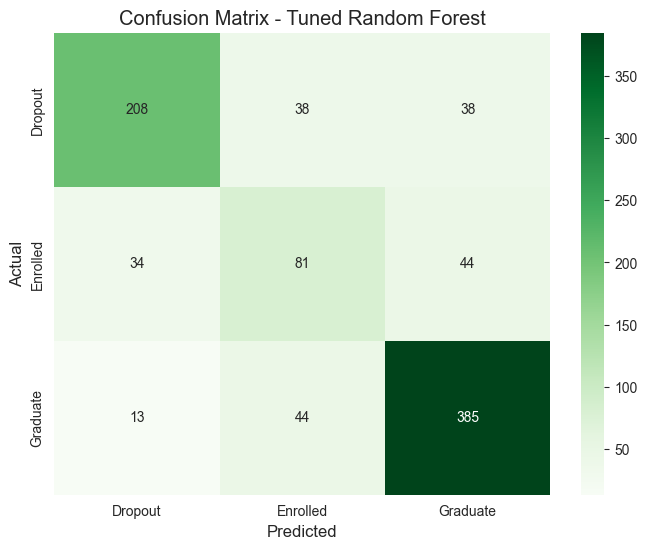

In [20]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42), 
                       param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train_best, y_train_res)
best_rf = grid_rf.best_estimator_
print("Best Parameters (Random Forest):", grid_rf.best_params_)
y_pred_rf = best_rf.predict(X_test_best)
print("\nAccuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.show()


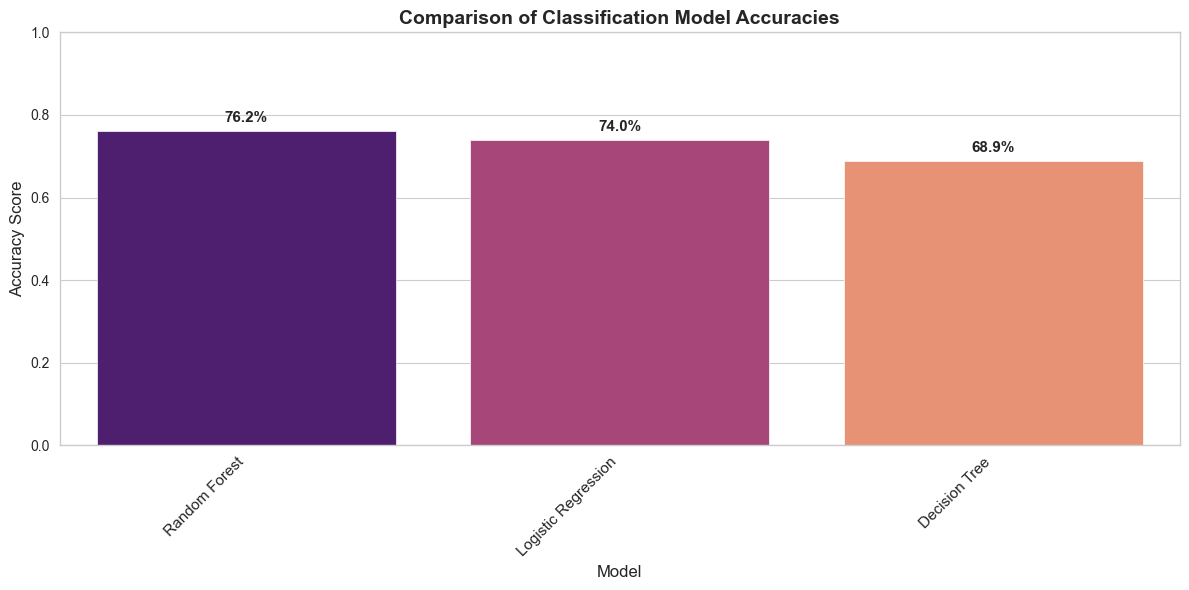

In [21]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
    ]
})

# Sorting the dataframe by Accuracy descending so bars are tallest to shortest
model_comparison = model_comparison.sort_values('Accuracy', ascending=False)

# Visualizing using a sorted Barplot (Vertical)
plt.figure(figsize=(12, 6))

# Creating the barplot and save it to 'ax' so we can attach text to it
ax = sns.barplot(
    x='Model', 
    y='Accuracy', 
    data=model_comparison, 
    palette='magma'
)

# Looping through each bar to add the percentage text right on top
for p in ax.patches:
    percentage = f'{p.get_height() * 100:.1f}%' 
    
    # Annotating the specific percentage string at the X, Y coordinate of the bar
    ax.annotate(percentage, 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', 
                va='center', 
                xytext=(0, 9),
                textcoords='offset points', 
                fontsize=11, 
                fontweight='bold')

plt.title('Comparison of Classification Model Accuracies', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy Score', fontsize=12)
plt.xlabel('Model', fontsize=12)

# Rotate x-axis labels so the long model names don't overlap
plt.xticks(rotation=45, ha='right', fontsize=11)

# Showing Accuracy ranges from 0 to 1 on the Y-axis
plt.ylim(0, 1.0)  

plt.tight_layout()
plt.show()
